Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")

Load Dataset

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx"
df = pd.read_excel(url, sheet_name="Year 2009-2010")

In [3]:
print(f"Dataset Shape: {df.shape}")
print("\nColumns and Data Types:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (525461, 8)

Columns and Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB
None

First 5 Rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W       

In [4]:
df['Revenue'] = df['Quantity'] * df['Price']

Missing and Duplicate Data Handling

In [5]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
print("Missing Values Summary:")
print(missing_df[missing_df['Missing Values'] > 0])

duplicate_count = df.duplicated().sum()
print(f"\nTotal Duplicate Rows Detected: {duplicate_count}")


Missing Values Summary:
             Missing Values  Percentage (%)
Description            2928        0.557225
Customer ID          107927       20.539488

Total Duplicate Rows Detected: 6865


Top 10 Best selling Products

In [8]:
# By Quantity
top_products_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("Top 10 Products by Quantity:")
print(top_products_qty)

Top 10 Products by Quantity:
Description
WHITE HANGING HEART T-LIGHT HOLDER    57733
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54698
BROCADE RING PURSE                    47647
PACK OF 72 RETRO SPOT CAKE CASES      46106
ASSORTED COLOUR BIRD ORNAMENT         44925
60 TEATIME FAIRY CAKE CASES           36326
PACK OF 60 PINK PAISLEY CAKE CASES    31822
JUMBO BAG RED RETROSPOT               30727
SMALL POPCORN HOLDER                  29500
STRAWBERRY CERAMIC TRINKET BOX        26563
Name: Quantity, dtype: int64


In [9]:
# By Revenue
top_products_rev = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print("Top 10 Products by Revenue:")
print(top_products_rev)

Top 10 Products by Revenue:
Description
REGENCY CAKESTAND 3 TIER               163051.46
WHITE HANGING HEART T-LIGHT HOLDER     157865.43
DOTCOM POSTAGE                         116401.99
ASSORTED COLOUR BIRD ORNAMENT           72454.12
PAPER CHAIN KIT 50'S CHRISTMAS          57870.20
JUMBO BAG RED RETROSPOT                 56444.61
PARTY BUNTING                           49645.52
ROTATING SILVER ANGELS T-LIGHT HLDR     47672.49
POSTAGE                                 46092.36
JUMBO BAG STRAWBERRY                    36699.61
Name: Revenue, dtype: float64


Sales Performance By Country

In [10]:
country_stats = df.groupby('Country').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('Revenue', 'sum'),
    Transaction_Count=('Invoice', 'nunique')
).sort_values(by='Total_Revenue', ascending=False)
print("Top 10 Countries by Total Revenue:")
print(country_stats.head(10))

Top 10 Countries by Total Revenue:
                Total_Quantity  Total_Revenue  Transaction_Count
Country                                                         
United Kingdom         4429046    8194777.533              26633
EIRE                    188704     352242.730                457
Netherlands             181823     263863.410                150
Germany                 107133     196290.351                513
France                   74471     130769.900                297
Sweden                   52238      51213.510                 83
Denmark                 227030      46972.950                 33
Switzerland              22053      43343.410                 50
Spain                    18332      37084.900                 85
Australia                20053      30051.800                 50


Plot Revenue

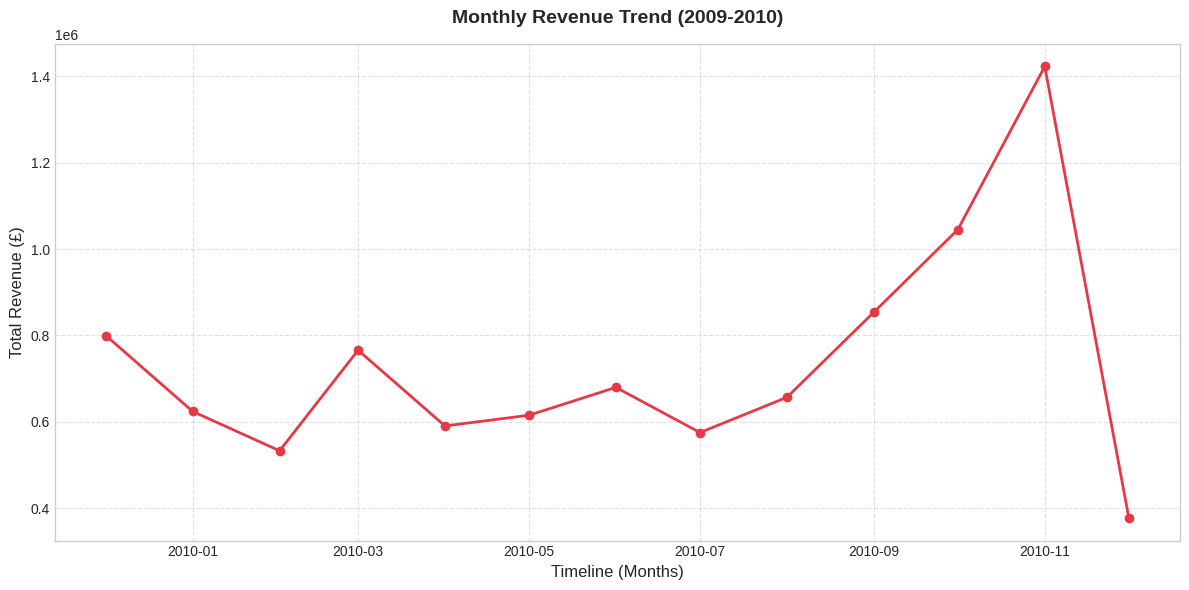

In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['Revenue'], marker='o', linewidth=2, color='#E63946')
plt.title('Monthly Revenue Trend (2009-2010)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline (Months)', fontsize=12)
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Correlation Heatmap

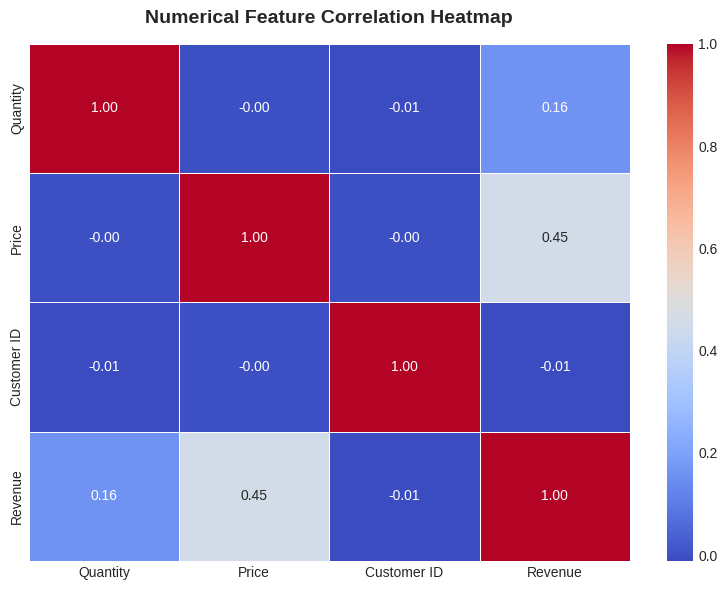

In [12]:
plt.figure(figsize=(8, 6))
# Select only numerical features for correlation
numerical_features = df[['Quantity', 'Price', 'Customer ID', 'Revenue']]
correlation_matrix = numerical_features.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Numerical Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Outlier Detection

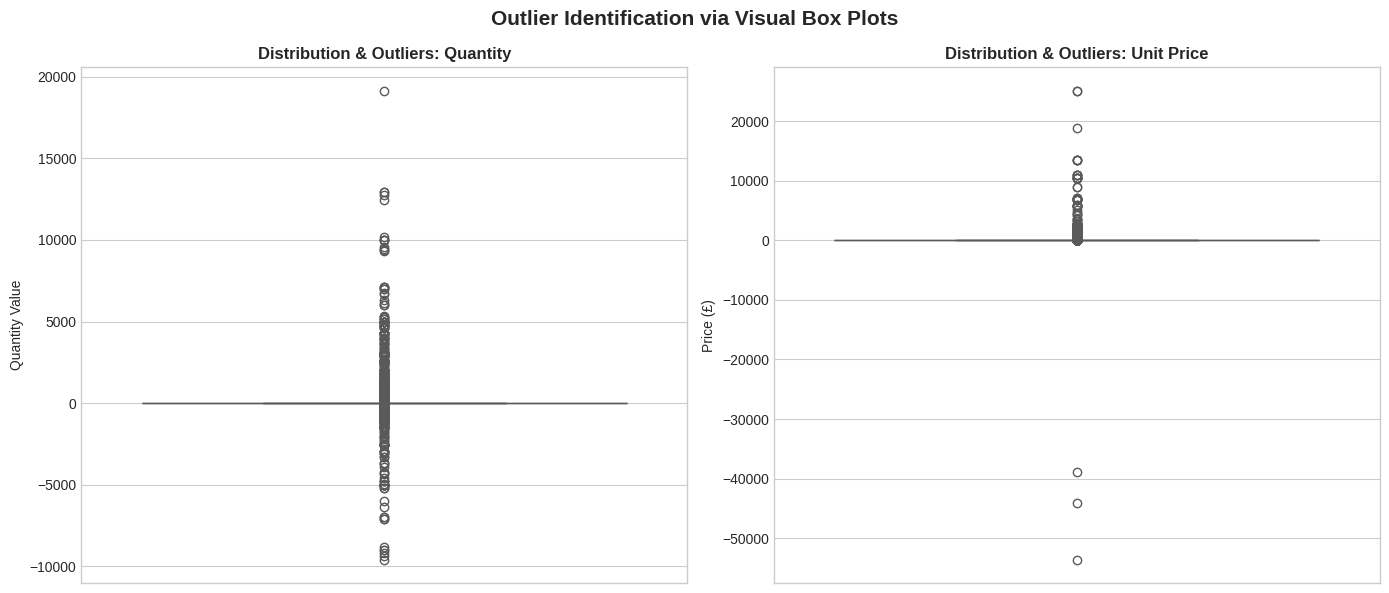

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot for Quantity
sns.boxplot(y=df['Quantity'], ax=axes[0], color='#4EA8DE')
axes[0].set_title('Distribution & Outliers: Quantity', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Quantity Value')

# Boxplot for Price
sns.boxplot(y=df['Price'], ax=axes[1], color='#48CAE4')
axes[1].set_title('Distribution & Outliers: Unit Price', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price (£)')

plt.suptitle('Outlier Identification via Visual Box Plots', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()